In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("advertising.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='str')

In [6]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
df = df.drop(columns=['Unnamed: 0'])

In [9]:
df.columns

Index(['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)',
       'Sales ($)'],
      dtype='str')

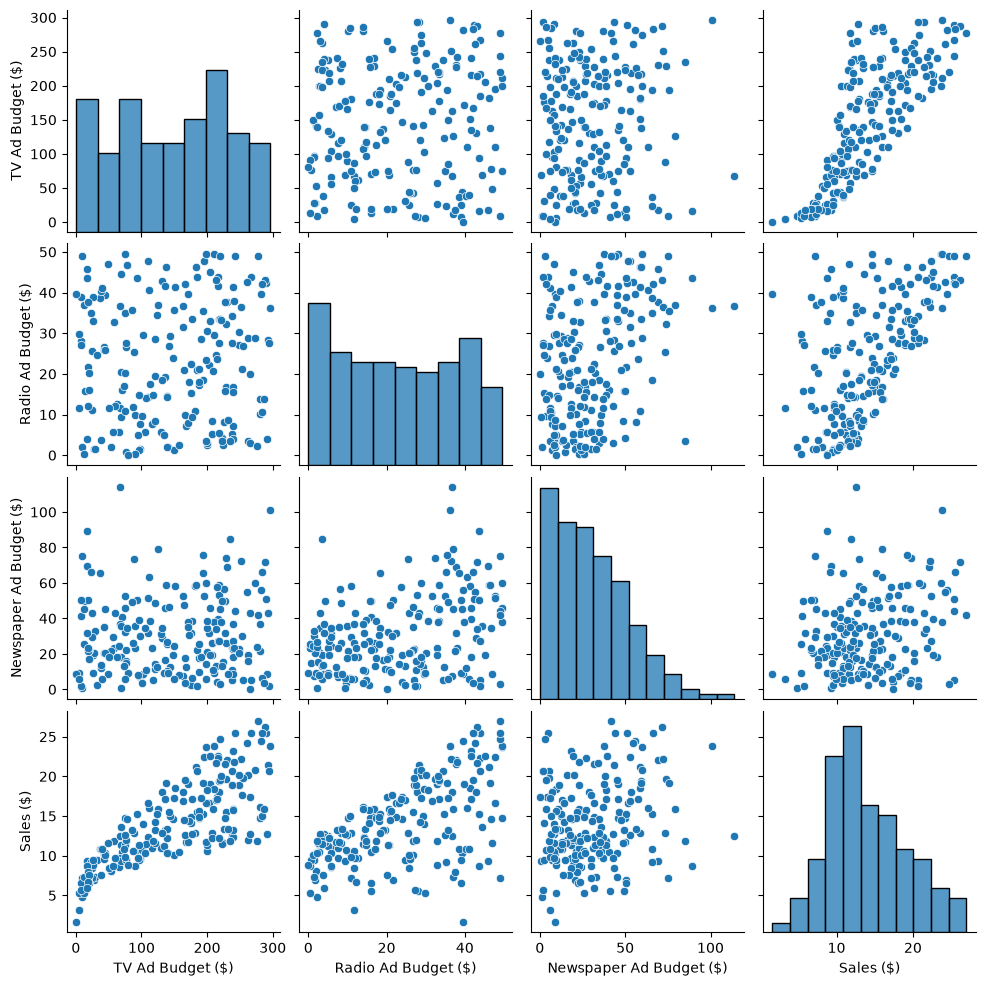

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

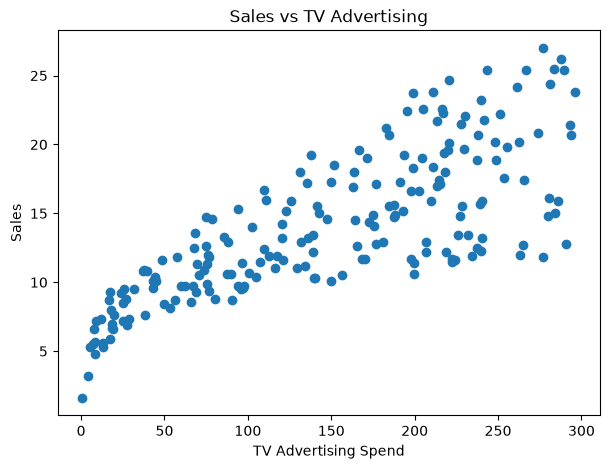

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(df['TV Ad Budget ($)'], df['Sales ($)'])
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('Sales vs TV Advertising')
plt.show()

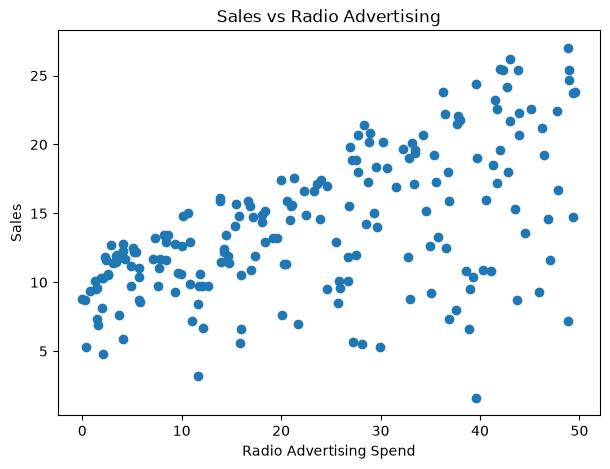

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(df['Radio Ad Budget ($)'], df['Sales ($)'])
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.title('Sales vs Radio Advertising')
plt.show()

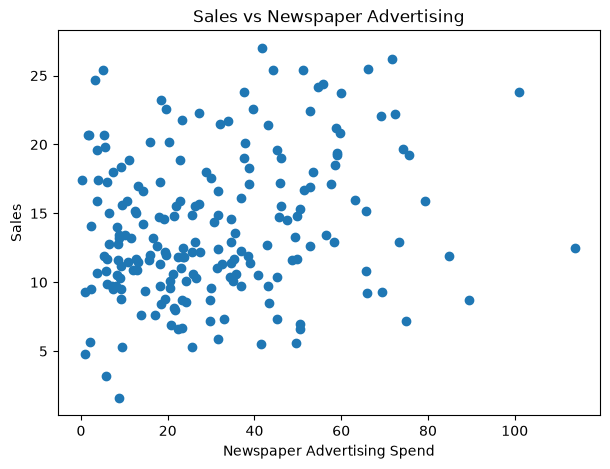

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df['Newspaper Ad Budget ($)'], df['Sales ($)'])
plt.xlabel('Newspaper Advertising Spend')
plt.ylabel('Sales')
plt.title('Sales vs Newspaper Advertising')
plt.show()

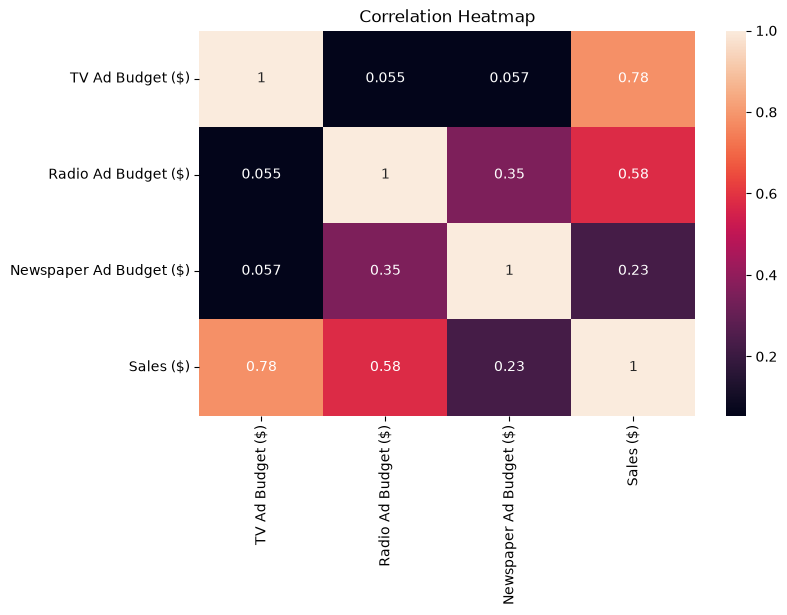

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [15]:
X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R²:", r2_score(y_test, lr_pred))

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))

Linear Regression
MAE: 1.4607567168117601
RMSE: 1.78159966153345
R²: 0.899438024100912

Random Forest
MAE: 0.6203249999999988
RMSE: 0.7687170968568338
R²: 0.9812782416450916


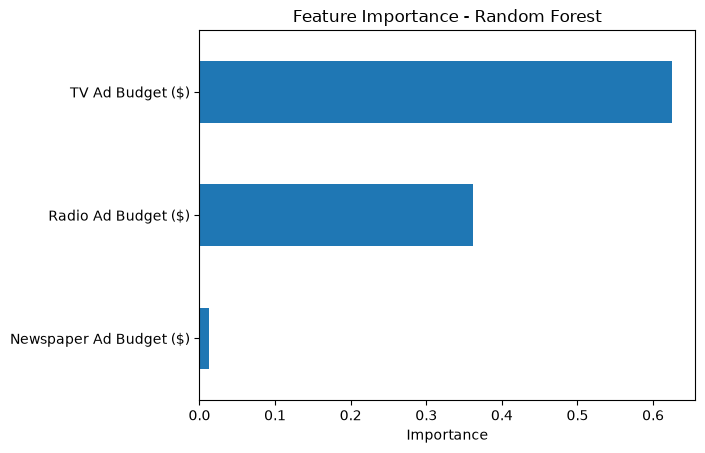

In [20]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()

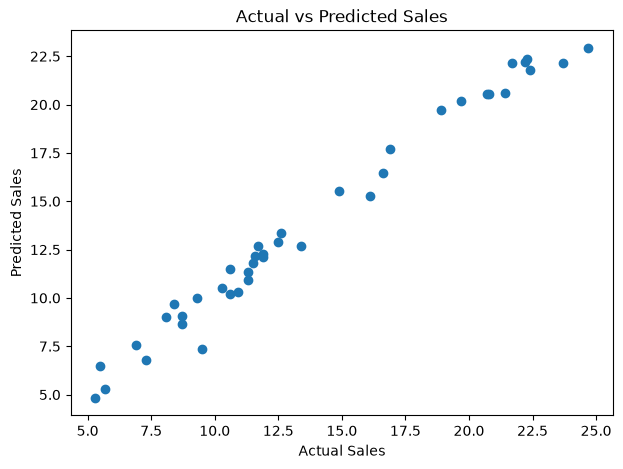

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

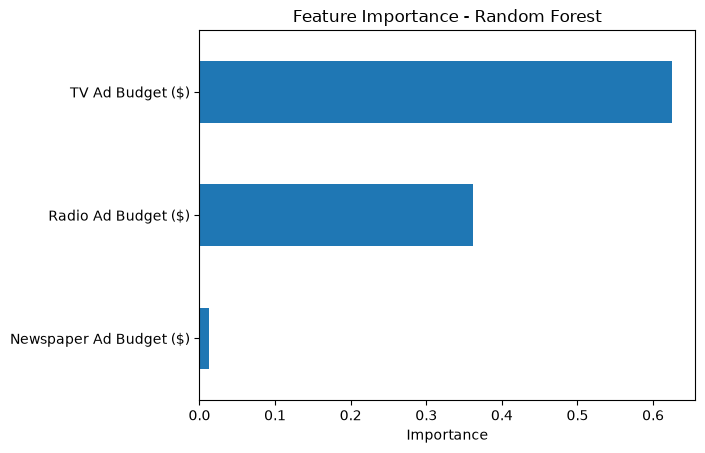

In [22]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()

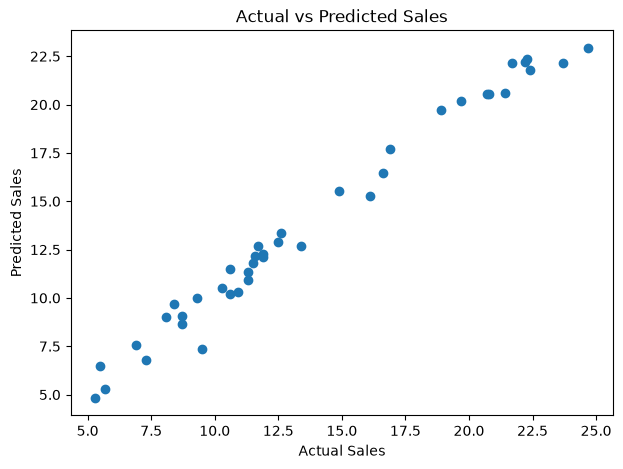

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

In [24]:
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': rf_pred
})

results.head(10)

,Actual Sales,Predicted Sales
95,16.9,17.698
15,22.4,21.804
30,21.4,20.619
158,7.3,6.793
128,24.7,22.927
115,12.6,13.379
69,22.3,22.376
170,8.4,9.688
174,11.5,11.826
45,14.9,15.540


In [25]:
import joblib

joblib.dump(rf_model, 'sales_prediction_model.pkl')

['sales_prediction_model.pkl']